# Hyperparameter Sweep Analysis (Multi-Probe)

This notebook analyzes results from W&B sweeps where each configuration was tested on 20 probe points.

Key metrics:
- `results/mean_delta_prob` - Average improvement across all probes
- `results/success_rate` - % of probes that flipped class
- `results/std_delta_prob` - Consistency measure
- `theory/mean_gap` - Theory-practice alignment

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Load Sweep Results

In [2]:
# Initialize W&B API
api = wandb.Api()

# TODO: Replace with your sweep info
entity = "jrosseruk"  # Your W&B username
project = "infusion-mnist"  # Your project name
sweep_id = "71yrlv36"  # Your sweep ID

sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
runs = sweep.runs

print(f"Loaded {len(runs)} runs from sweep {sweep_id}")
print(f"Sweep method: {sweep.config['method']}")
print(f"Sweep metric: {sweep.config['metric']['name']} ({sweep.config['metric']['goal']})")

Loaded 49 runs from sweep 71yrlv36
Sweep method: bayes
Sweep metric: results/mean_delta_prob (maximize)


In [3]:
# Convert to DataFrame
import json

summary_list = []
config_list = []
name_list = []

for run in runs:
    # Only include finished runs
    if run.state == "finished":
        # print(type(run.summary._json_dict))
        summary_list.append(json.loads(run.summary._json_dict))
        # Handle both old and new config formats
        try:
            config_list.append({k: v["value"] for k, v in json.loads(run.config).items() if not k.startswith('_')})
        except:
            config_list.append({k: v for k, v in run.config.items() if not k.startswith('_')})
        name_list.append(run.name)

summary_df = pd.DataFrame.from_records(summary_list)
config_df = pd.DataFrame.from_records(config_list)
name_df = pd.DataFrame({'run_name': name_list})

# Combine into single DataFrame
df = pd.concat([name_df, config_df, summary_df], axis=1)

print(f"\nSuccessfully loaded {len(df)} finished runs")
print(f"\nConfig columns: {config_df.columns.tolist()}")
# print(f"\nMetric columns: {[c for c in summary_df.columns if not c.startswith('_')]}")
df.head()


Successfully loaded 8 finished runs

Config columns: ['alpha', 'top_k', 'epochs', 'damping', 'epsilon', 'n_steps', 'batch_size', 'model_type', 'random_seed', 'learning_rate', 'samples_per_class']


,run_name,alpha,top_k,epochs,damping,epsilon,n_steps,batch_size,model_type,random_seed,...,results/positive_improvement_rate,results/std_delta_prob,results/success_rate,theory/mean_actual_delta_f,theory/mean_gap,theory/mean_predicted_delta_f,theory/median_gap,timing/initial_train,timing/per_probe,timing/total
0,likely-sweep-11,0.011681,76,92,0.088679,1.098663,50,128,attention,100,...,0.6,0.076250,0.00,0.501517,180.884321,181.385838,63.001406,3.563653,34.936559,698.731181
1,fast-sweep-14,0.038132,84,125,0.202176,0.043445,50,64,attention,12,...,0.5,0.051673,0.05,-0.084719,12.280020,12.195301,8.668820,15.780781,37.103759,742.075189
2,volcanic-sweep-25,0.011082,98,16,0.089108,0.307114,20,32,attention,100,...,0.4,0.058269,0.00,-0.216064,191.968714,191.752650,47.777932,3.663409,38.616594,772.331871
3,dark-sweep-39,0.002418,65,149,0.019394,1.462754,100,128,attention,100,...,0.8,0.094717,0.00,2.392287,128.928889,131.321177,78.862435,10.732008,26.297902,525.958033
4,valiant-sweep-37,0.043808,82,85,0.073135,1.772670,50,64,attention,12,...,0.8,0.067901,0.05,2.507767,75.901750,78.409517,76.154293,8.192566,41.907134,838.142681


## 2. Summary Statistics

In [4]:
# Key metrics for multi-probe evaluation
key_metrics = [
    'results/mean_delta_prob',  # Primary metric
    'results/median_delta_prob',
    'results/std_delta_prob',
    'results/success_rate',
    'results/positive_improvement_rate',
    'theory/mean_gap',
]

print("=" * 70)
print("OVERALL STATISTICS")
print("=" * 70)
print(df[key_metrics].describe())

print(f"\n{'='*70}")
print("SUCCESS RATES")
print('='*70)
print(f"Mean success rate (class flip): {df['results/success_rate'].mean()*100:.1f}%")
print(f"Mean positive improvement rate: {df['results/positive_improvement_rate'].mean()*100:.1f}%")
if 'results/large_improvement_rate' in df.columns:
    print(f"Mean large improvement rate (>10%): {df['results/large_improvement_rate'].mean()*100:.1f}%")

OVERALL STATISTICS
       results/mean_delta_prob  results/median_delta_prob  \
count                 8.000000                   8.000000   
mean                  0.019941                   0.000004   
std                   0.027813                   0.002912   
min                  -0.020354                  -0.006525   
25%                  -0.000804                  -0.000015   
50%                   0.016515                   0.000329   
75%                   0.047896                   0.001113   
max                   0.054606                   0.002862   

       results/std_delta_prob  results/success_rate  \
count                8.000000              8.000000   
mean                 0.099088              0.037500   
std                  0.051173              0.051755   
min                  0.051673              0.000000   
25%                  0.065493              0.000000   
50%                  0.082118              0.025000   
75%                  0.112268              0.0

## 3. Best Runs Analysis

In [5]:
# Top 10 runs by mean probability increase
target_metric = 'results/mean_delta_prob'
top_runs = df.nlargest(10, target_metric)

# Show key parameters
param_cols = ['model_type', 'epsilon', 'damping', 'alpha', 'top_k', 'n_steps', 'learning_rate', 'epochs']
result_cols = [
    'results/mean_delta_prob',
    'results/success_rate',
    'results/std_delta_prob',
    'theory/mean_gap'
]

print("=" * 70)
print("TOP 10 RUNS")
print("=" * 70)
display(top_runs[['run_name'] + param_cols + result_cols])

TOP 10 RUNS


,run_name,model_type,epsilon,damping,alpha,top_k,n_steps,learning_rate,epochs,results/mean_delta_prob,results/success_rate,results/std_delta_prob,theory/mean_gap
7,fast-sweep-52,attention,1.631732,0.036368,0.004529,90,50,0.002805,140,0.054606,0.15,0.190989,249.517876
6,ancient-sweep-51,attention,0.055850,0.029195,0.003584,70,20,0.000936,148,0.048611,0.05,0.164922,26.438397
3,dark-sweep-39,attention,1.462754,0.019394,0.002418,65,100,0.006618,149,0.047657,0.00,0.094717,128.928889
4,valiant-sweep-37,attention,1.772670,0.073135,0.043808,82,50,0.007554,85,0.017045,0.05,0.067901,75.901750
1,fast-sweep-14,attention,0.043445,0.202176,0.038132,84,50,0.000158,125,0.015986,0.05,0.051673,12.280020
0,likely-sweep-11,attention,1.098663,0.088679,0.011681,76,50,0.000767,92,0.000402,0.00,0.076250,180.884321
2,volcanic-sweep-25,attention,0.307114,0.089108,0.011082,98,20,0.001429,16,-0.004424,0.00,0.058269,191.968714
5,iconic-sweep-46,attention,0.171985,0.138493,0.022878,49,20,0.000433,46,-0.020354,0.00,0.087986,37.693797


In [6]:
# Best parameters summary
print("\nBEST PARAMETER DISTRIBUTIONS")
print("=" * 70)
for param in param_cols:
    if param in ['model_type']:
        # Categorical
        if param in top_runs.columns and len(top_runs[param].mode()) > 0:
            mode_val = top_runs[param].mode()[0]
            print(f"{param:20s}: {mode_val} (appears {(top_runs[param] == mode_val).sum()}/10 times)")
    else:
        # Numerical
        if param in top_runs.columns:
            print(f"{param:20s}: mean={top_runs[param].mean():.4f}, std={top_runs[param].std():.4f}, median={top_runs[param].median():.4f}")


BEST PARAMETER DISTRIBUTIONS
model_type          : attention (appears 8/10 times)
epsilon             : mean=0.8180, std=0.7490, median=0.7029
damping             : mean=0.0846, std=0.0616, median=0.0809
alpha               : mean=0.0173, std=0.0161, median=0.0114
top_k               : mean=76.7500, std=15.4064, median=79.0000
n_steps             : mean=45.0000, std=26.7261, median=50.0000
learning_rate       : mean=0.0026, std=0.0029, median=0.0012
epochs              : mean=100.1250, std=49.5564, median=108.5000


## 4. Multi-Probe Robustness Analysis

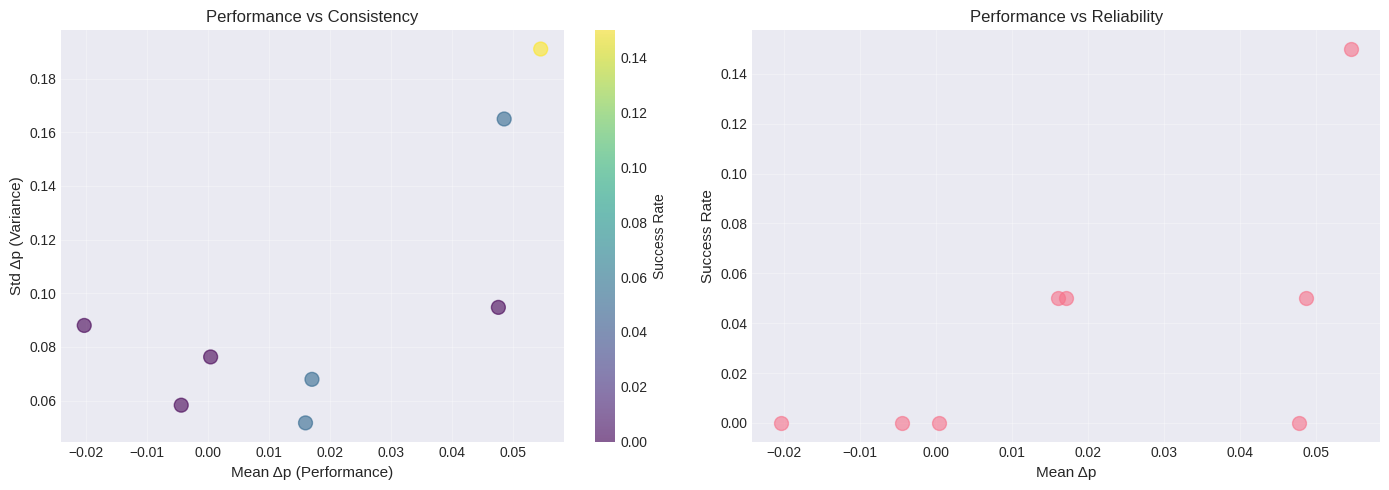


ROBUSTNESS INSIGHTS:
Robust runs (high mean, low std): 0


In [7]:
# Analyze mean vs std trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean vs Std
axes[0].scatter(df['results/mean_delta_prob'], df['results/std_delta_prob'], 
                alpha=0.6, s=100, c=df['results/success_rate'], cmap='viridis')
axes[0].set_xlabel('Mean Δp (Performance)', fontsize=11)
axes[0].set_ylabel('Std Δp (Variance)', fontsize=11)
axes[0].set_title('Performance vs Consistency', fontsize=12)
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Success Rate', fontsize=10)

# Mean vs Success Rate
axes[1].scatter(df['results/mean_delta_prob'], df['results/success_rate'], 
                alpha=0.6, s=100)
axes[1].set_xlabel('Mean Δp', fontsize=11)
axes[1].set_ylabel('Success Rate', fontsize=11)
axes[1].set_title('Performance vs Reliability', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nROBUSTNESS INSIGHTS:")
print("=" * 70)
# Find runs with high mean and low std
robust_runs = df[(df['results/mean_delta_prob'] > df['results/mean_delta_prob'].quantile(0.75)) & 
                 (df['results/std_delta_prob'] < df['results/std_delta_prob'].quantile(0.25))]
print(f"Robust runs (high mean, low std): {len(robust_runs)}")
if len(robust_runs) > 0:
    print(f"  Mean epsilon: {robust_runs['epsilon'].mean():.3f}")
    print(f"  Mean damping: {robust_runs['damping'].mean():.3f}")
    print(f"  Mean success rate: {robust_runs['results/success_rate'].mean():.2%}")

## 5. Parameter Importance Analysis

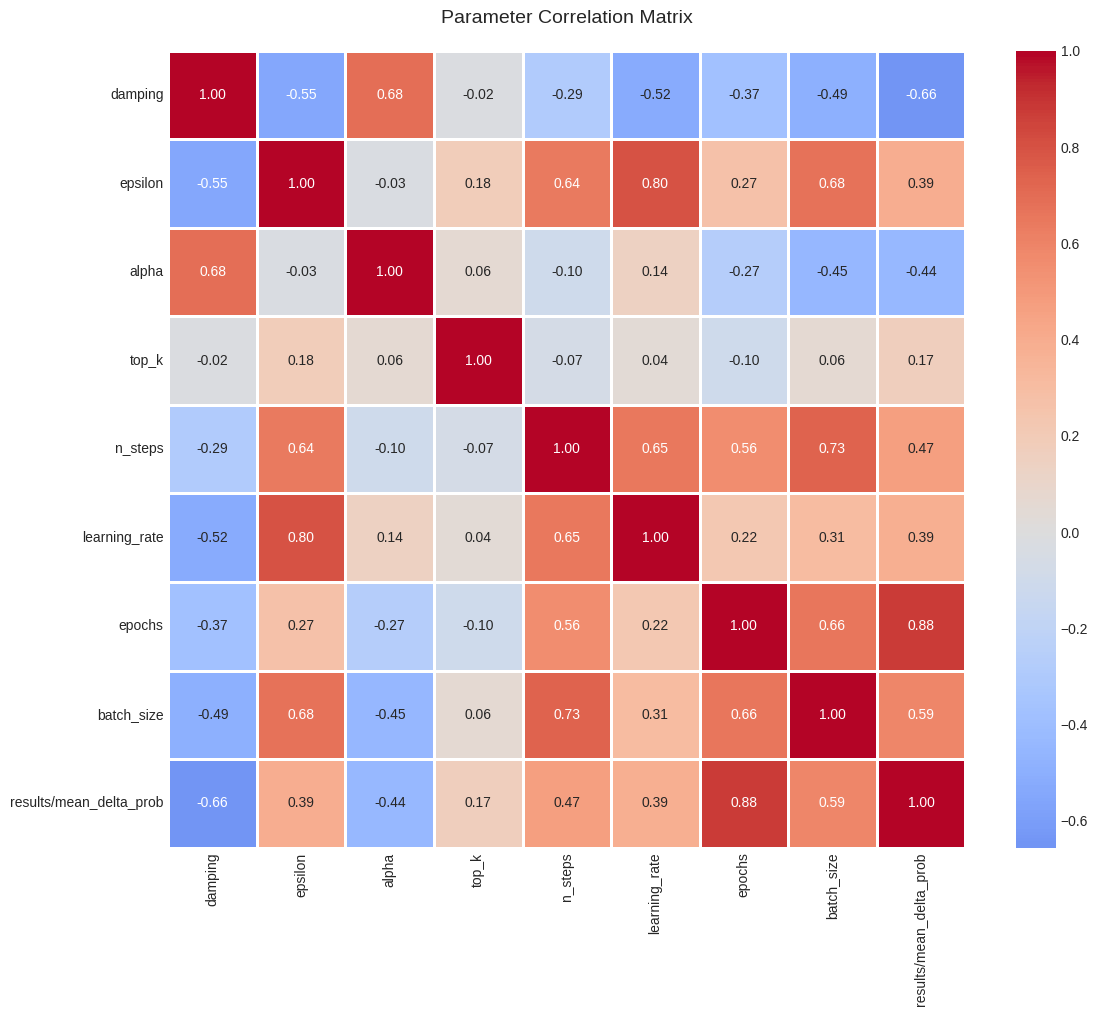


CORRELATIONS WITH MEAN DELTA PROB
epochs              : +0.875
batch_size          : +0.590
n_steps             : +0.474
epsilon             : +0.394
learning_rate       : +0.386
top_k               : +0.170
alpha               : -0.438
damping             : -0.656


In [8]:
# Correlation matrix
params = ['damping', 'epsilon', 'alpha', 'top_k', 'n_steps', 'learning_rate', 'epochs', 'batch_size']
available_params = [p for p in params if p in df.columns]

# Only use numerical columns
corr_data = df[available_params + [target_metric]].select_dtypes(include=[np.number])
corr_matrix = corr_data.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Parameter Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Print correlations with target
print("\nCORRELATIONS WITH MEAN DELTA PROB")
print("=" * 70)
target_corrs = corr_matrix[target_metric].drop(target_metric).sort_values(ascending=False)
for param, corr in target_corrs.items():
    print(f"{param:20s}: {corr:+.3f}")

## 6. Individual Parameter Effects

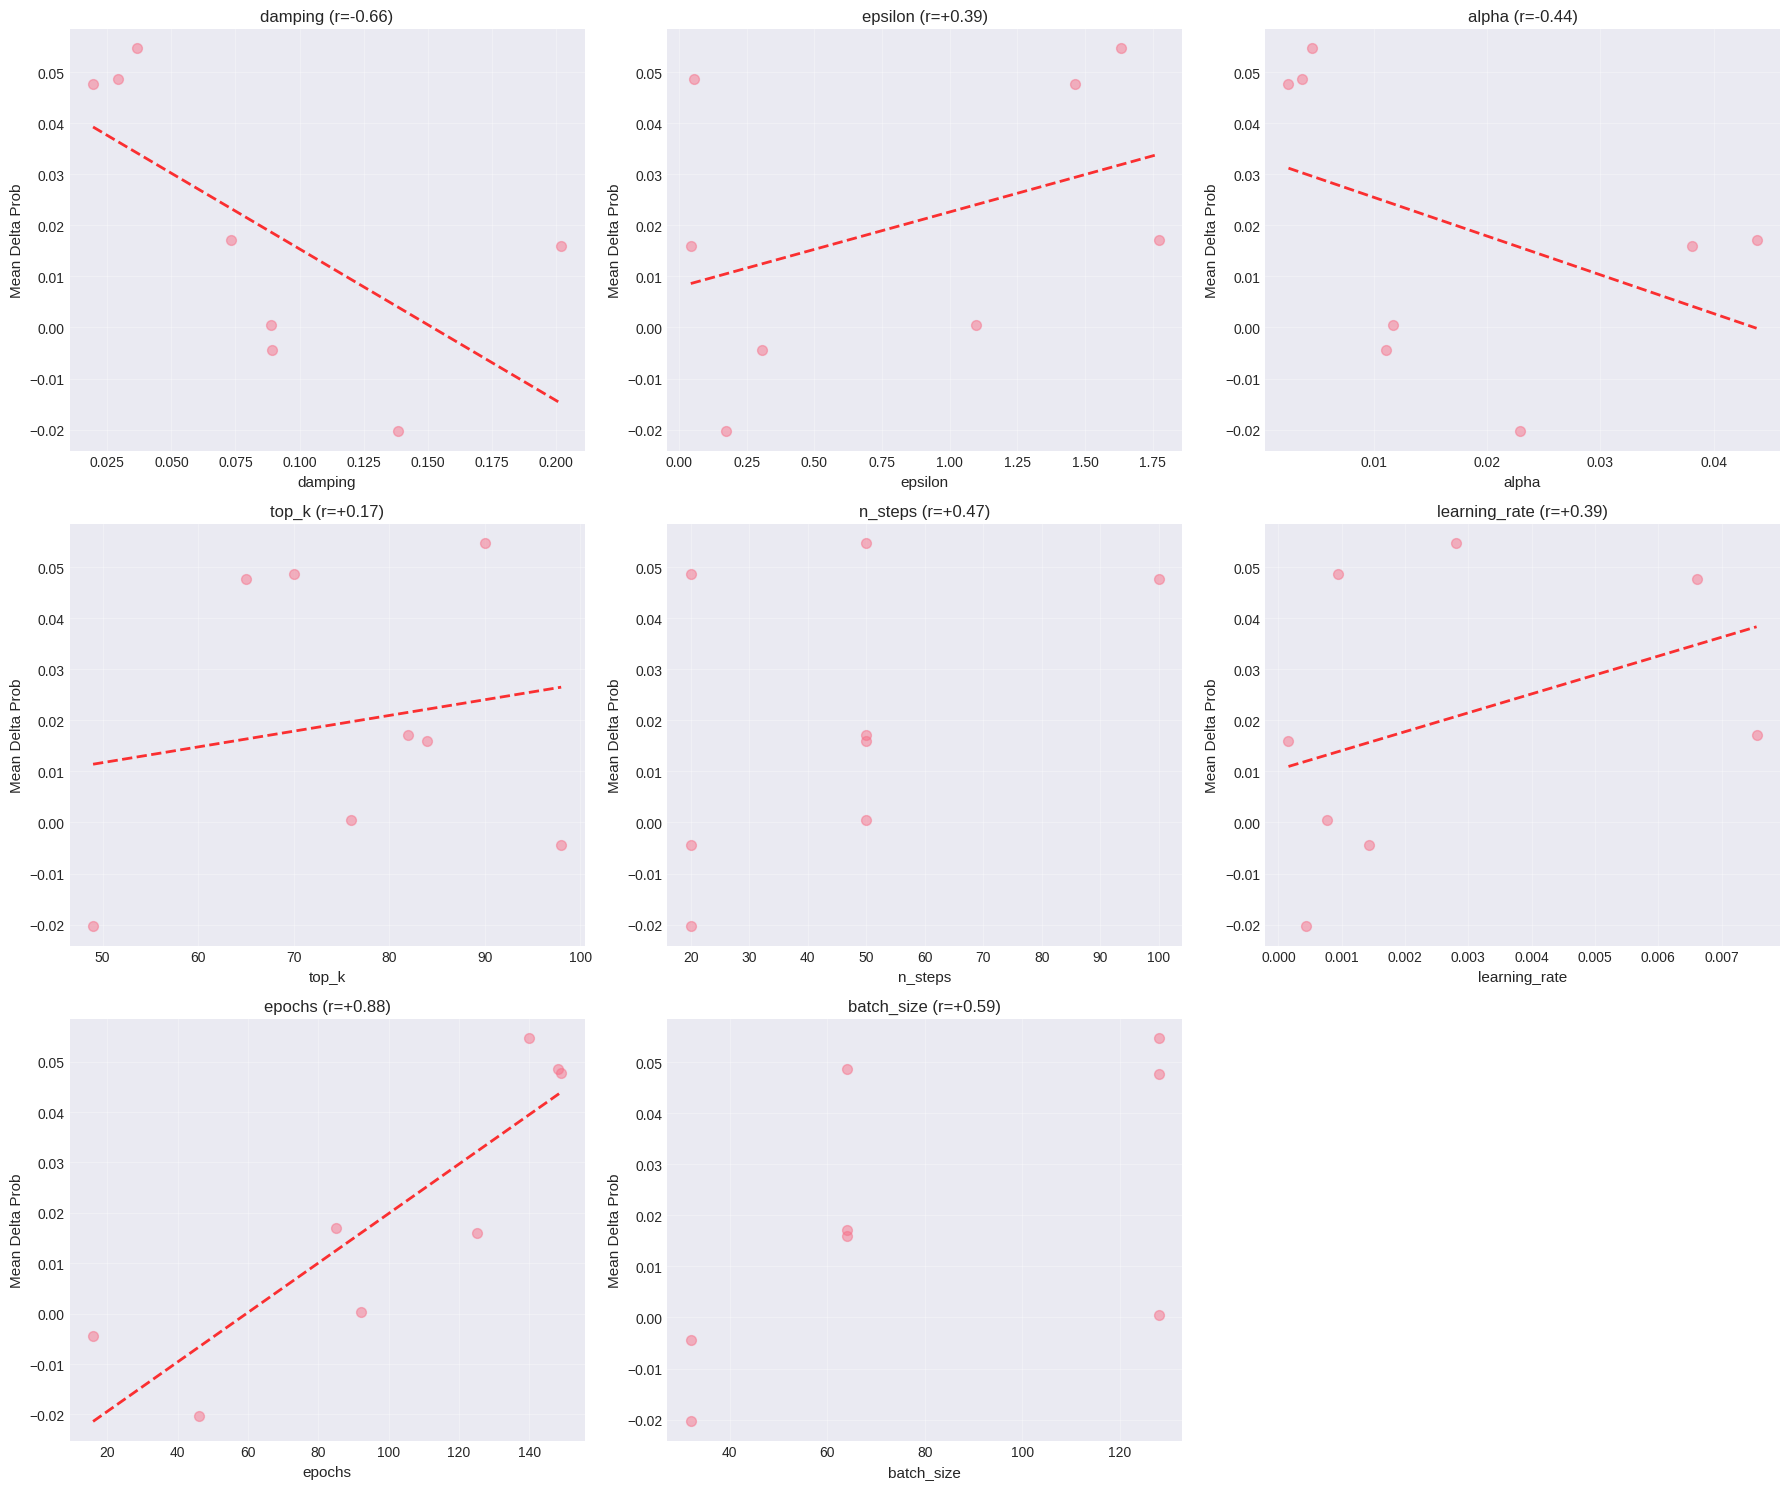

In [9]:
# Plot each parameter vs performance
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, param in enumerate(available_params):
    if i >= len(axes):
        break
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(df[param], df[target_metric], alpha=0.5, s=50)
    
    # Add trend line
    if df[param].nunique() > 5:  # Only for continuous variables
        valid_idx = df[param].notna() & df[target_metric].notna()
        if valid_idx.sum() > 2:
            z = np.polyfit(df.loc[valid_idx, param], df.loc[valid_idx, target_metric], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df[param].min(), df[param].max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Mean Delta Prob', fontsize=11)
    
    # Add correlation in title
    if param in target_corrs.index:
        corr = target_corrs[param]
        ax.set_title(f'{param} (r={corr:+.2f})', fontsize=12)
    else:
        ax.set_title(f'{param}', fontsize=12)
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for i in range(len(available_params), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 7. Epsilon Analysis

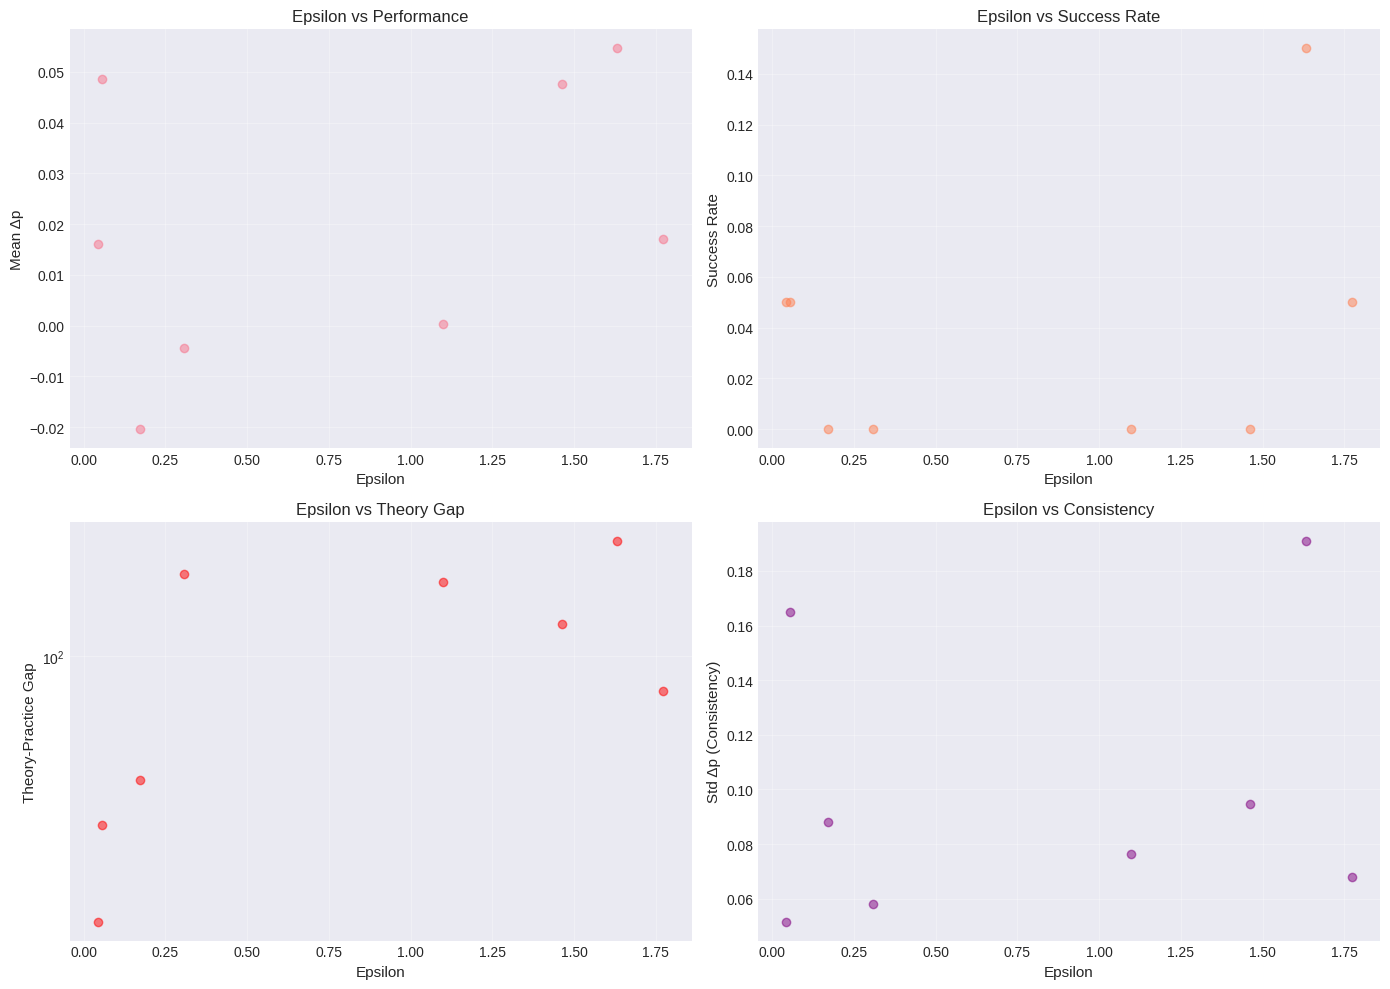

In [10]:
# Epsilon analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Epsilon vs mean performance
axes[0, 0].scatter(df['epsilon'], df['results/mean_delta_prob'], alpha=0.5)
axes[0, 0].set_xlabel('Epsilon', fontsize=11)
axes[0, 0].set_ylabel('Mean Δp', fontsize=11)
axes[0, 0].set_title('Epsilon vs Performance', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Epsilon vs success rate
axes[0, 1].scatter(df['epsilon'], df['results/success_rate'], alpha=0.5, color='coral')
axes[0, 1].set_xlabel('Epsilon', fontsize=11)
axes[0, 1].set_ylabel('Success Rate', fontsize=11)
axes[0, 1].set_title('Epsilon vs Success Rate', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Epsilon vs theory gap
axes[1, 0].scatter(df['epsilon'], df['theory/mean_gap'], alpha=0.5, color='red')
axes[1, 0].set_xlabel('Epsilon', fontsize=11)
axes[1, 0].set_ylabel('Theory-Practice Gap', fontsize=11)
axes[1, 0].set_title('Epsilon vs Theory Gap', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Epsilon vs consistency (std)
axes[1, 1].scatter(df['epsilon'], df['results/std_delta_prob'], alpha=0.5, color='purple')
axes[1, 1].set_xlabel('Epsilon', fontsize=11)
axes[1, 1].set_ylabel('Std Δp (Consistency)', fontsize=11)
axes[1, 1].set_title('Epsilon vs Consistency', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Theory vs Practice

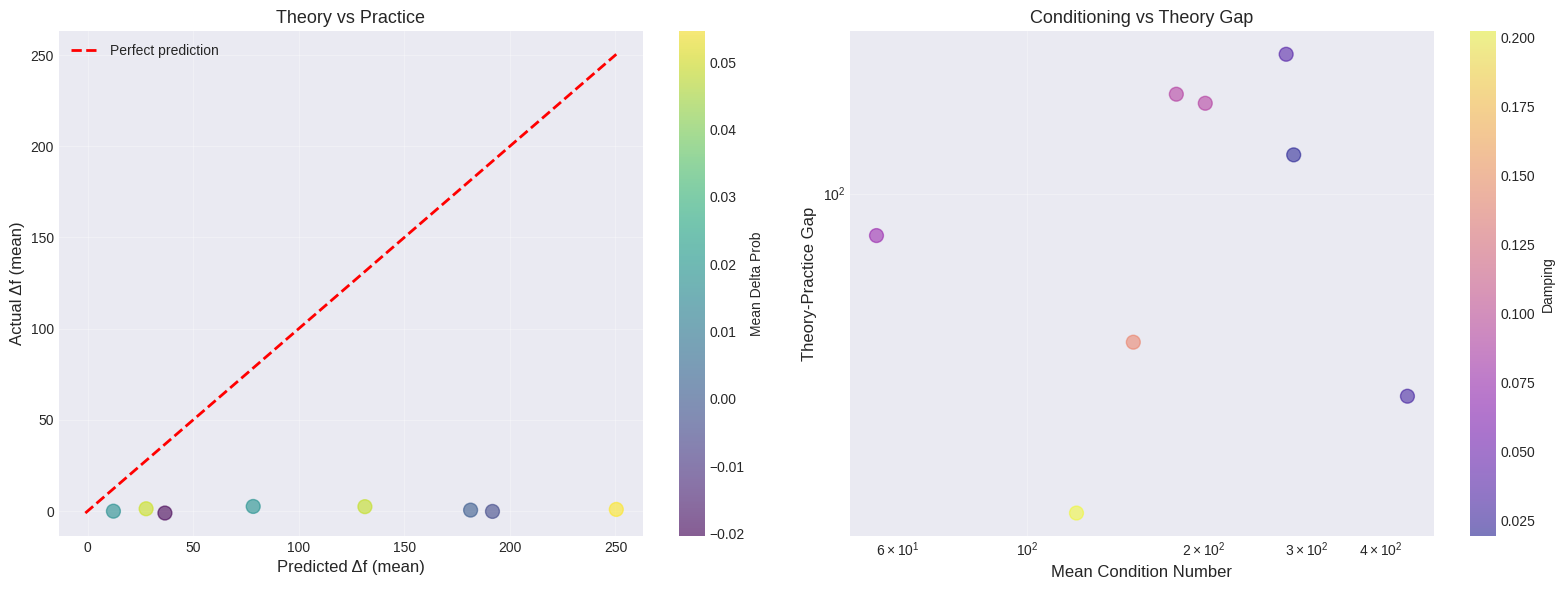


THEORY-PRACTICE ALIGNMENT
Mean theory gap: 112.9517
Median theory gap: 102.4153
Correlation (predicted vs actual): r=0.100, p=8.1341e-01


In [11]:
if 'theory/mean_predicted_delta_f' in df.columns and 'theory/mean_actual_delta_f' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Predicted vs Actual
    ax = axes[0]
    scatter = ax.scatter(
        df['theory/mean_predicted_delta_f'],
        df['theory/mean_actual_delta_f'],
        c=df['results/mean_delta_prob'],
        cmap='viridis',
        alpha=0.6,
        s=100
    )

    # Perfect prediction line
    min_val = min(df['theory/mean_predicted_delta_f'].min(), df['theory/mean_actual_delta_f'].min())
    max_val = max(df['theory/mean_predicted_delta_f'].max(), df['theory/mean_actual_delta_f'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

    ax.set_xlabel('Predicted Δf (mean)', fontsize=12)
    ax.set_ylabel('Actual Δf (mean)', fontsize=12)
    ax.set_title('Theory vs Practice', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Mean Delta Prob')

    # Theory gap vs condition number
    ax = axes[1]
    if 'hessian/mean_cond_num' in df.columns:
        scatter = ax.scatter(
            df['hessian/mean_cond_num'],
            df['theory/mean_gap'],
            alpha=0.5,
            s=100,
            c=df['damping'],
            cmap='plasma'
        )
        ax.set_xlabel('Mean Condition Number', fontsize=12)
        ax.set_ylabel('Theory-Practice Gap', fontsize=12)
        ax.set_title('Conditioning vs Theory Gap', fontsize=13)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Damping')

    plt.tight_layout()
    plt.show()

    # Statistics
    print("\nTHEORY-PRACTICE ALIGNMENT")
    print("=" * 70)
    print(f"Mean theory gap: {df['theory/mean_gap'].mean():.4f}")
    print(f"Median theory gap: {df['theory/mean_gap'].median():.4f}")
    
    # Correlation
    valid_idx = df['theory/mean_predicted_delta_f'].notna() & df['theory/mean_actual_delta_f'].notna()
    if valid_idx.sum() > 2:
        corr, pval = stats.pearsonr(
            df.loc[valid_idx, 'theory/mean_predicted_delta_f'],
            df.loc[valid_idx, 'theory/mean_actual_delta_f']
        )
        print(f"Correlation (predicted vs actual): r={corr:.3f}, p={pval:.4e}")

## 9. Recommendations

In [12]:
print("=" * 70)
print("RECOMMENDED PARAMETER RANGES (based on top 10% of runs)")
print("=" * 70)

# Get top 10% of runs
top_10pct = df.nlargest(max(1, len(df) // 10), target_metric)

for param in available_params:
    if param in ['model_type']:
        if len(top_10pct[param].mode()) > 0:
            mode_val = top_10pct[param].mode()[0]
            print(f"\n{param}:")
            print(f"  Recommended: {mode_val}")
    else:
        q25 = top_10pct[param].quantile(0.25)
        q75 = top_10pct[param].quantile(0.75)
        median = top_10pct[param].median()
        print(f"\n{param}:")
        print(f"  Recommended range: [{q25:.4f}, {q75:.4f}]")
        print(f"  Median: {median:.4f}")

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Best epsilon range
best_runs = df[df['results/mean_delta_prob'] > df['results/mean_delta_prob'].quantile(0.75)]
print(f"\n1. Epsilon Sweet Spot:")
print(f"   Optimal range: {best_runs['epsilon'].quantile(0.25):.3f} - {best_runs['epsilon'].quantile(0.75):.3f}")

# Consistency leaders
consistent_runs = df[df['results/std_delta_prob'] < df['results/std_delta_prob'].quantile(0.25)]
print(f"\n2. Consistency:")
print(f"   Most consistent runs (low std): {len(consistent_runs)}")
print(f"   Their mean performance: {consistent_runs['results/mean_delta_prob'].mean():.4f}")
print(f"   Their typical epsilon: {consistent_runs['epsilon'].median():.3f}")
print(f"   Their typical damping: {consistent_runs['damping'].median():.3f}")

# High success rate configs
reliable_runs = df[df['results/success_rate'] > df['results/success_rate'].quantile(0.75)]
print(f"\n3. Reliability (High Success Rate):")
print(f"   High success rate runs (>75th percentile): {len(reliable_runs)}")
print(f"   Mean success rate: {reliable_runs['results/success_rate'].mean():.2%}")
print(f"   Mean performance: {reliable_runs['results/mean_delta_prob'].mean():.4f}")

RECOMMENDED PARAMETER RANGES (based on top 10% of runs)

damping:
  Recommended range: [0.0364, 0.0364]
  Median: 0.0364

epsilon:
  Recommended range: [1.6317, 1.6317]
  Median: 1.6317

alpha:
  Recommended range: [0.0045, 0.0045]
  Median: 0.0045

top_k:
  Recommended range: [90.0000, 90.0000]
  Median: 90.0000

n_steps:
  Recommended range: [50.0000, 50.0000]
  Median: 50.0000

learning_rate:
  Recommended range: [0.0028, 0.0028]
  Median: 0.0028

epochs:
  Recommended range: [140.0000, 140.0000]
  Median: 140.0000

batch_size:
  Recommended range: [128.0000, 128.0000]
  Median: 128.0000

KEY INSIGHTS

1. Epsilon Sweet Spot:
   Optimal range: 0.450 - 1.238

2. Consistency:
   Most consistent runs (low std): 2
   Their mean performance: 0.0058
   Their typical epsilon: 0.175
   Their typical damping: 0.146

3. Reliability (High Success Rate):
   High success rate runs (>75th percentile): 1
   Mean success rate: 15.00%
   Mean performance: 0.0546


## 10. Export Best Configuration

In [13]:
# Get best run
best_run = df.loc[df[target_metric].idxmax()]

# Extract configuration
best_config = {}
for param in ['model_type', 'batch_size', 'samples_per_class', 'learning_rate', 
              'epochs', 'damping', 'top_k', 'epsilon', 'alpha', 'n_steps', 'random_seed']:
    if param in best_run:
        val = best_run[param]
        if param in ['batch_size', 'samples_per_class', 'epochs', 'top_k', 'n_steps', 'random_seed']:
            best_config[param] = int(val)
        elif param != 'model_type':
            best_config[param] = float(val)
        else:
            best_config[param] = val

print("BEST CONFIGURATION")
print("=" * 70)
print(f"Run name: {best_run['run_name']}")
print(f"Mean delta prob: {best_run['results/mean_delta_prob']:.4f}")
print(f"Success rate: {best_run['results/success_rate']:.2%}")
print(f"Std delta prob: {best_run['results/std_delta_prob']:.4f}")
print("\nConfiguration:")
for key, value in best_config.items():
    print(f"  {key}: {value}")

# Save to file
import json
with open('best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print("\nSaved to best_config.json")

BEST CONFIGURATION
Run name: fast-sweep-52
Mean delta prob: 0.0546
Success rate: 15.00%
Std delta prob: 0.1910

Configuration:
  model_type: attention
  batch_size: 128
  samples_per_class: 108
  learning_rate: 0.002805084827828345
  epochs: 140
  damping: 0.036368399944171154
  top_k: 90
  epsilon: 1.631731554128384
  alpha: 0.004528534240434361
  n_steps: 50
  random_seed: 256

Saved to best_config.json
